In [1]:
import pandas as pd
import os

In [2]:
load_dir = r"C:\Users\olish\Documents\ml_projects\Steps_Predictor\model\data\clean\steps"

dfs = {}

for file_name in os.listdir(load_dir):
    if file_name.endswith(".pkl"):
        file_path = os.path.join(load_dir, file_name)
        
        df_name = file_name.replace(".pkl", "")
        dfs[df_name] = pd.read_pickle(file_path)

In [3]:
import pandas as pd

In [4]:
df1 = dfs["oli"].reset_index()['value']
df1.head()

0     4390
1     8335
2     6946
3     8350
4    11054
Name: value, dtype: int64

In [5]:
df1.tail()

2067     5479
2068     8883
2069    14678
2070     8999
2071     9725
Name: value, dtype: int64

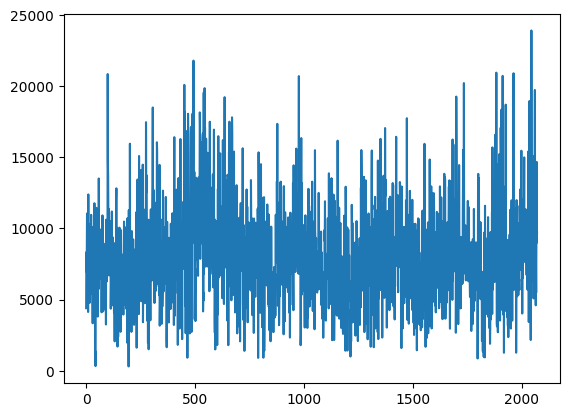

In [6]:
import matplotlib.pyplot as plt
plt.plot(df1)

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
SCALER=MinMaxScaler(feature_range=(0,1))
df1=SCALER.fit_transform(np.array(df1).reshape(-1,1))

In [8]:
print(df1)

[[0.17344563]
 [0.34041563]
 [0.28162695]
 ...
 [0.60887967]
 [0.36851907]
 [0.39924662]]


In [ ]:
TRAINING_SIZE=int(len(df1)*0.65)
TEST_SIZE=len(df1)-TRAINING_SIZE
train_data,test_data=df1[0:TRAINING_SIZE,:],df1[TRAINING_SIZE:len(df1),:1]

In [10]:
TRAINING_SIZE, TEST_SIZE

(1346, 726)

In [11]:
train_data

array([[0.17344563],
       [0.34041563],
       [0.28162695],
       ...,
       [0.33355906],
       [0.20222627],
       [0.30202734]])

In [12]:
def create_dataset(dataset, time_step=1):
	dataX, dataY = [], []
	for i in range(len(dataset) - time_step - 1):
		a = dataset[i:(i + time_step), 0]
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return np.array(dataX), np.array(dataY)

time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [13]:
print(X_train.shape), print(y_train.shape)

(1245, 100)
(1245,)


(None, None)

In [14]:
print(X_test.shape), print(y_test.shape)

(625, 100)
(625,)


(None, None)

In [15]:
X_train =X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

In [ ]:
%pip install tensorflow

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [17]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(100,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')

c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available:  0


In [20]:
model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100,batch_size=64,verbose=1)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 147ms/step - loss: 0.0580 - val_loss: 0.0197
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - loss: 0.0191 - val_loss: 0.0197
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0193 - val_loss: 0.0201
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0206 - val_loss: 0.0199
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.0210 - val_loss: 0.0196
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0207 - val_loss: 0.0198
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0203 - val_loss: 0.0198
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0214 - val_loss: 0.0198
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.0199 - val_loss: 0.0201
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - loss: 0.0214 - val_loss: 0.0197
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0202 - val_loss: 0.0197
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 

In [21]:
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [ ]:
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

In [23]:
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

8342.368594363423

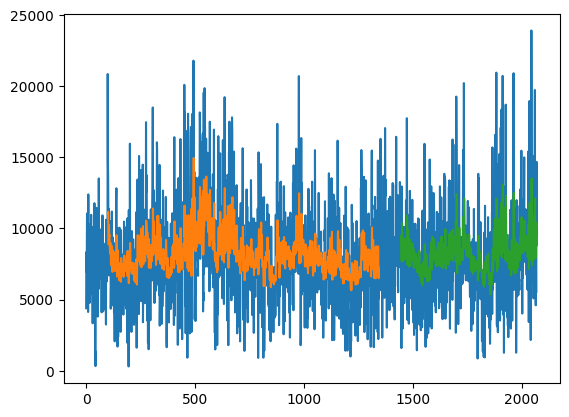

In [24]:
look_back=100

train_predict_plot=np.empty_like(df1)
train_predict_plot[:,:]=np.nan
train_predict_plot[look_back:len(train_predict)+look_back,:]=train_predict

test_predict_plot=np.empty_like(df1)
test_predict_plot[:,:]=np.nan   
test_predict_plot[len(train_predict)+(look_back*2)+1:len(df1)-1,:]=test_predict

plt.plot(scaler.inverse_transform(df1))
plt.plot(train_predict_plot)
plt.plot(test_predict_plot)
plt.show()